In [41]:
!pip install transformers

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

In [43]:
df=pd.read_csv('/content/IMDB Dataset.csv')

In [44]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Initial Observation:
1. The dataset contains movie reviews and their sentiment labels.
2. The main input column is 'review' and the target column is 'sentiment'.
3. We will inspect shape, data types, missing values, duplicates, and class balance before modeling.

In [45]:
df.shape

(50000, 2)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


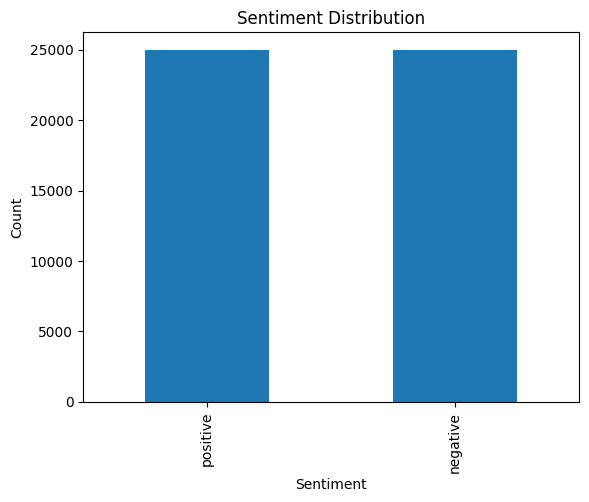

In [47]:
df["sentiment"].value_counts().plot(kind="bar")

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.show()

In [48]:
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

print("\nClass distribution:")
print(df["sentiment"].value_counts())

print("\nClass percentage:")
print(df["sentiment"].value_counts(normalize=True) * 100)

Total rows: 50000
Total columns: 2

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Class percentage:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


Observation:
1. The dataset has two main columns: review and sentiment.
2. The sentiment classes are approximately balanced, so class imbalance is not a major concern.

In [49]:
df.isnull().sum()

,0
review,0
sentiment,0


In [50]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [51]:
df.duplicated().sum()

np.int64(418)

In [52]:
df = df.drop_duplicates()

In [53]:
df["sentiment"].unique()

array(['positive', 'negative'], dtype=object)

In [54]:
df["review_length"] = df["review"].apply(len)
df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [55]:
df["review_length"] = df["review"].apply(len)

df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [56]:
Q1 = df["review_length"].quantile(0.25)
Q3 = df["review_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[
    (df["review_length"] < lower_bound) |
    (df["review_length"] > upper_bound)
]

print("Number of review-length outliers:", len(outliers))

Q1: 699.0
Q3: 1592.0
IQR: 893.0
Lower Bound: -640.5
Upper Bound: 2931.5
Number of review-length outliers: 3705


Outlier Decision:
1. Some reviews are much longer than most others, but these are not necessarily data errors.
2. Since long movie reviews are valid text, they are retained instead of being removed.
3. The Transformer pipeline will handle excessive sequence length using truncation.

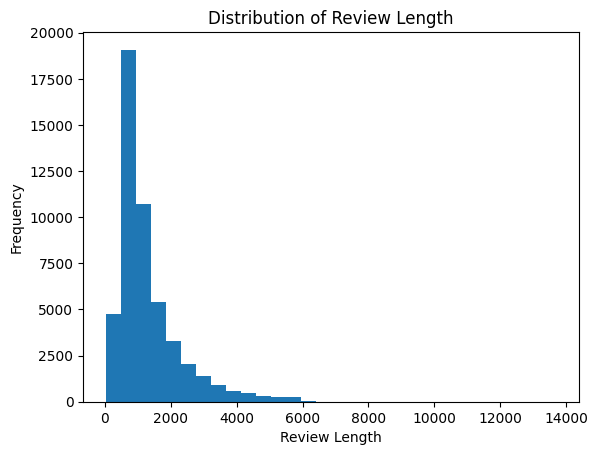

In [57]:
plt.hist(df["review_length"], bins=30)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length")
plt.show()

In [58]:
df.sort_values("review_length").head()

,review,sentiment,review_length
27521,"Read the book, forget the movie!",negative,32
31072,"What a script, what a story, what a mess!",negative,41
40817,I hope this group of film-makers never re-unites.,negative,49
28920,Primary plot!Primary direction!Poor interpreta...,negative,51
19874,This movie is terrible but it has some good ef...,negative,52


In [59]:
df.sort_values("review_length", ascending=False).head()

,review,sentiment,review_length
31481,Match 1: Tag Team Table Match Bubba Ray and Sp...,positive,13704
40521,There's a sign on The Lost Highway that says:<...,positive,12988
31240,"(Some spoilers included:)<br /><br />Although,...",positive,12930
31436,"Back in the mid/late 80s, an OAV anime by titl...",positive,12129
5708,**Attention Spoilers**<br /><br />First of all...,positive,10363


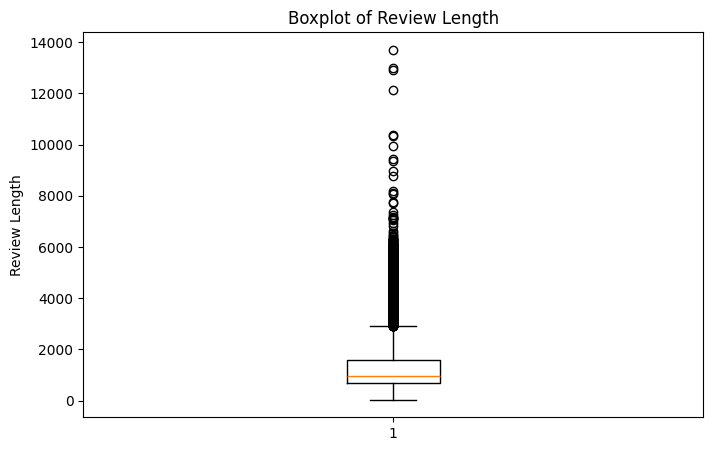

In [60]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["review_length"])
plt.ylabel("Review Length")
plt.title("Boxplot of Review Length")
plt.show()

Observation:
1. The boxplot shows that review length has several high-value outliers.
2. These are retained because long reviews can still be valid movie reviews.

/tmp/ipykernel_4076/1592361922.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


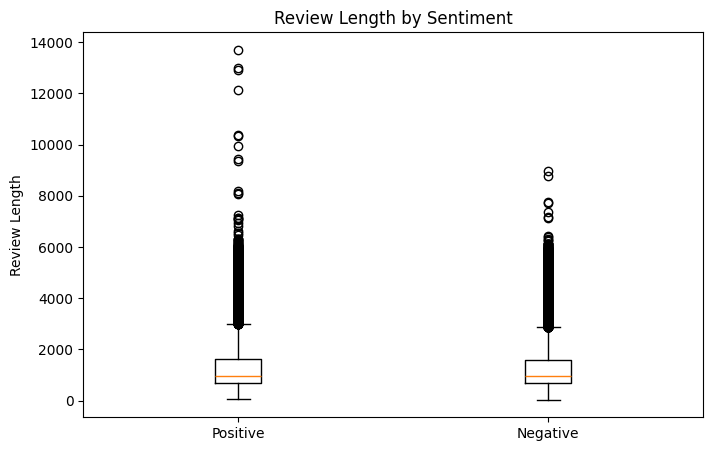

In [61]:
positive_lengths = df[df["sentiment"] == "positive"]["review_length"]
negative_lengths = df[df["sentiment"] == "negative"]["review_length"]
plt.figure(figsize=(8, 5))
plt.boxplot(
    [positive_lengths, negative_lengths],
    labels=["Positive", "Negative"]
)
plt.ylabel("Review Length")
plt.title("Review Length by Sentiment")
plt.show()

Observation:
1. This plot compares review-length distributions between positive and negative reviews.
2. It helps us check whether one sentiment tends to have longer reviews than the other.

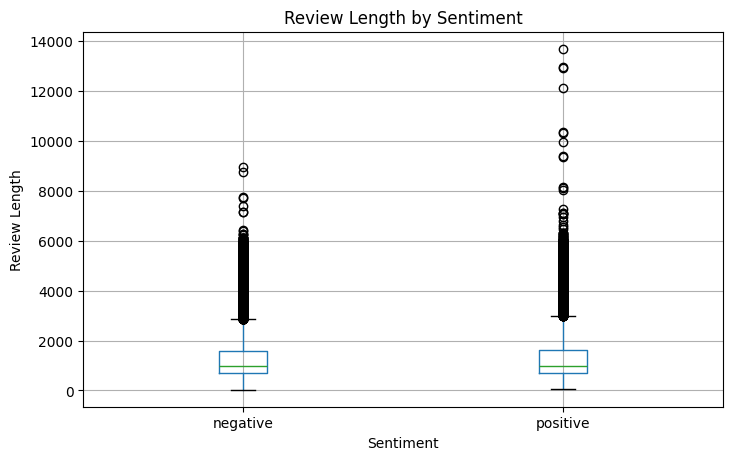

In [62]:
df.boxplot(
    column="review_length",
    by="sentiment",
    figsize=(8, 5)
)
plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")
plt.show()

Sentiment bar chart observation:
1. Positive and negative sentiment classes are approximately balanced.

Histogram observation:
1. Review lengths are right-skewed, with most reviews concentrated at lower lengths and a smaller number of very long reviews.

Boxplot observation:
1. Several long reviews appear as outliers, but they are retained because they are valid text.

Sentiment-vs-length boxplot:
1. The plot allows comparison of typical review lengths across positive and negative classes.

In [63]:
sample = df.sample(n=100, random_state=42).copy()
sample.shape

(100, 3)

In [64]:
sample["sentiment"].value_counts()

,count
sentiment,
negative,53
positive,47


In [65]:
sentiment_model = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [66]:
predictions = sentiment_model(
    sample["review"].tolist(),
    truncation=True
)

In [67]:
predictions[:5]

[{'label': 'NEGATIVE', 'score': 0.9995367527008057},
 {'label': 'POSITIVE', 'score': 0.9961833357810974},
 {'label': 'NEGATIVE', 'score': 0.9773180484771729},
 {'label': 'NEGATIVE', 'score': 0.9991605281829834},
 {'label': 'POSITIVE', 'score': 0.5168048143386841}]

In [68]:
sample["predicted_label"] = [
    pred["label"] for pred in predictions
]

In [69]:
sample["confidence"] = [
    pred["score"] for pred in predictions
]

In [70]:
sample["true_label"] = sample["sentiment"].str.upper()

In [71]:
sample[
    ["review", "true_label", "predicted_label", "confidence"]
].head()

,review,true_label,predicted_label,confidence
29171,"""Soul Plane"" is a horrible attempt at comedy t...",NEGATIVE,NEGATIVE,0.999537
43589,Guest from the Future tells a fascinating stor...,POSITIVE,POSITIVE,0.996183
38712,"""National Treasure"" (2004) is a thoroughly mis...",NEGATIVE,NEGATIVE,0.977318
16045,"OK. First said, I just wanted to check whether...",NEGATIVE,NEGATIVE,0.999161
5248,"I haven't always been a fan, but the show grew...",POSITIVE,POSITIVE,0.516805


In [72]:
sample["correct"] = (
    sample["true_label"] == sample["predicted_label"]
)

In [73]:
sample[
    ["true_label", "predicted_label", "correct"]
].head()

,true_label,predicted_label,correct
29171,NEGATIVE,NEGATIVE,True
43589,POSITIVE,POSITIVE,True
38712,NEGATIVE,NEGATIVE,True
16045,NEGATIVE,NEGATIVE,True
5248,POSITIVE,POSITIVE,True


In [74]:
accuracy = sample["correct"].mean()
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9
Accuracy Percentage: 90.0 %


In [75]:
sample["correct"].value_counts()

,count
correct,
True,90
False,10


In [76]:
for i, row in sample.head(5).iterrows():

    print("Review:")
    print(row["review"])
    print("\nTrue Label:", row["true_label"])
    print("Predicted Label:", row["predicted_label"])
    print("Confidence:", row["confidence"])
    print("-" * 80)

Review:
"Soul Plane" is a horrible attempt at comedy that only should appeal people with thick skulls, bloodshot eyes and furry pawns. <br /><br />The plot is not only incoherent but also non-existent, acting is mostly sub sub-par with a gang of highly moronic and dreadful characters thrown in for bad measure, jokes are often spotted miles ahead and almost never even a bit amusing. This movie lacks any structure and is full of racial stereotypes that must have seemed old even in the fifties, the only thing it really has going for it is some pretty ladies, but really, if you want that you can rent something from the "Adult" section. OK?<br /><br />I can hardly see anything here to recommend since you'll probably have a lot a better and productive time chasing rats with a sledgehammer or inventing waterproof teabags or whatever.<br /><br />2/10

True Label: NEGATIVE
Predicted Label: NEGATIVE
Confidence: 0.9995367527008057
------------------------------------------------------------------

In [77]:
wrong_predictions = sample[
    sample["true_label"] != sample["predicted_label"]
]
wrong_predictions[
    ["review", "true_label", "predicted_label", "confidence"]
].head()

,review,true_label,predicted_label,confidence
47783,His significant charisma and commanding presen...,NEGATIVE,POSITIVE,0.995536
49366,I admire Deepa Mehta and this movie is a maste...,POSITIVE,NEGATIVE,0.996170
46007,Stardust Another Guarded Review (originally wr...,POSITIVE,NEGATIVE,0.911088
42037,It is a great tragedy that both Richard Harris...,NEGATIVE,POSITIVE,0.840920
49029,"In the eighties, Savage Steve Holland put out ...",POSITIVE,NEGATIVE,0.975386


Attention allows a Transformer to understand relationships between words and determine which words are important based on the surrounding context. Bag-of-Words only counts words and does not understand word order or relationships between words.